<a href="https://colab.research.google.com/github/Santhoshbabu009/192324146-ITA0604-MACHINE-LEARNING/blob/main/MLLAB_1_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Training data
data = {
    'Sky': ['Sunny','Sunny','Rainy','Sunny'],
    'AirTemp': ['Warm','Warm','Cold','Warm'],
    'Humidity': ['Normal','High','High','High'],
    'Wind': ['Strong','Strong','Strong','Strong'],
    'Water': ['Warm','Warm','Warm','Cool'],
    'Forecast': ['Same','Same','Change','Same'],
    'EnjoySport': ['Yes','Yes','No','Yes']
}

df = pd.DataFrame(data)

concepts = df.iloc[:, :-1].values
target = df.iloc[:, -1].values

hypothesis = concepts[0].copy()

for i in range(len(concepts)):
    if target[i] == "Yes":
        for j in range(len(hypothesis)):
            if hypothesis[j] != concepts[i][j]:
                hypothesis[j] = "?"

print("Most Specific Hypothesis:")
print(hypothesis)

Most Specific Hypothesis:
['Sunny' 'Warm' '?' 'Strong' '?' 'Same']


In [2]:
import pandas as pd

data = {
    'Sky':['Sunny','Sunny','Rainy','Sunny'],
    'AirTemp':['Warm','Warm','Cold','Warm'],
    'Humidity':['Normal','High','High','High'],
    'Wind':['Strong','Strong','Strong','Strong'],
    'Water':['Warm','Warm','Warm','Cool'],
    'Forecast':['Same','Same','Change','Same'],
    'EnjoySport':['Yes','Yes','No','Yes']
}

df = pd.DataFrame(data)

concepts = df.iloc[:,:-1].values
target = df.iloc[:,-1].values

specific = concepts[0].copy()
general = [["?" for i in range(len(specific))] for j in range(len(specific))]

for i, h in enumerate(concepts):

    if target[i] == "Yes":
        for x in range(len(specific)):
            if h[x] != specific[x]:
                specific[x] = '?'
                general[x][x] = '?'

    if target[i] == "No":
        for x in range(len(specific)):
            if h[x] != specific[x]:
                general[x][x] = specific[x]
            else:
                general[x][x] = '?'

general = [g for g in general if g != ['?']*len(specific)]

print("Specific Hypothesis")
print(specific)

print("\nGeneral Hypothesis")
for g in general:
    print(g)

Specific Hypothesis
['Sunny' 'Warm' '?' 'Strong' '?' 'Same']

General Hypothesis
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']
['?', '?', '?', '?', '?', 'Same']


Accuracy: 0.9777777777777777


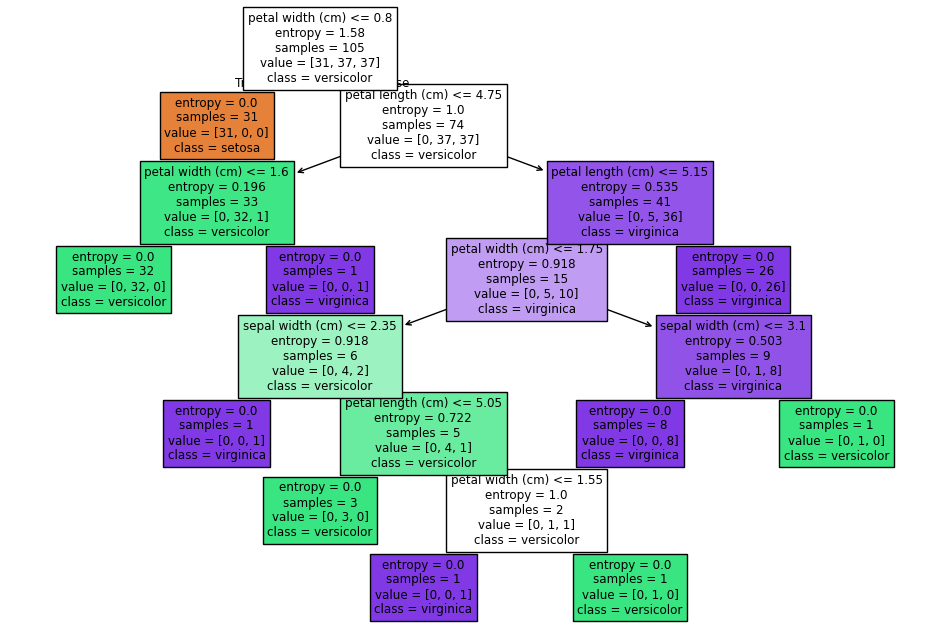

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state=42
)

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,prediction))

Accuracy: 1.0


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 1.0


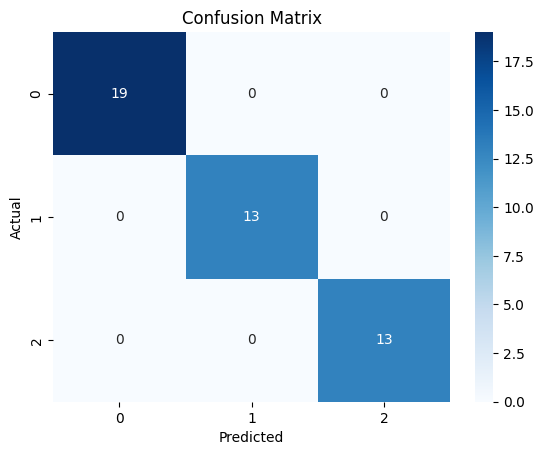

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()

X_train,X_test,y_train,y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,prediction))

cm = confusion_matrix(y_test,prediction)

sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.9777777777777777


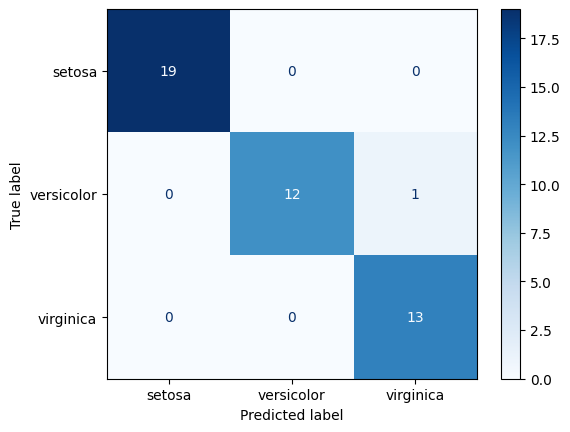

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.show()

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.5558915986952422
R2 Score: 0.5757877060324524


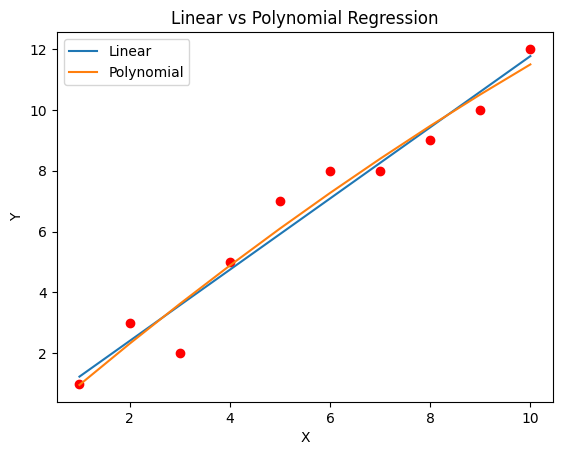

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample Data
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([1,3,2,5,7,8,8,9,10,12])

# Linear Regression
linear = LinearRegression()
linear.fit(X, y)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Plot
plt.scatter(X, y, color='red')

plt.plot(X, linear.predict(X), label="Linear")

plt.plot(
    X,
    poly_model.predict(X_poly),
    label="Polynomial"
)

plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.show()

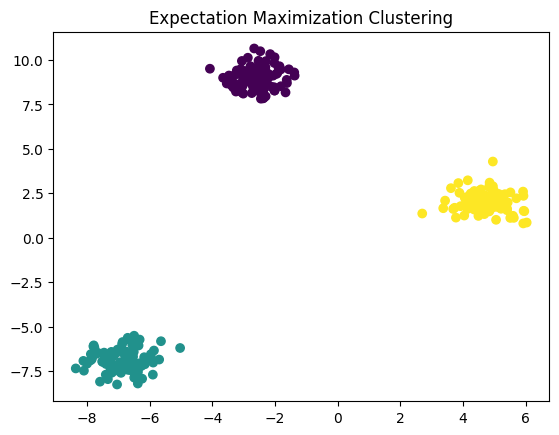

In [10]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Generate Dataset
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

# EM Algorithm
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X)

labels = gmm.predict(X)

# Plot Clusters
plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap="viridis"
)

plt.title("Expectation Maximization Clustering")
plt.show()

In [11]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# New Sample Prediction
sample = [[5.1, 3.5, 1.4, 0.2]]
print("Predicted Class:", iris.target_names[knn.predict(sample)[0]])

Accuracy: 1.0
Predicted Class: setosa


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Sample Dataset
data = {
    "Year":[2018,2017,2019,2015,2020,2016],
    "Mileage":[30000,45000,20000,60000,15000,50000],
    "Price":[600000,500000,700000,400000,800000,450000]
}

df = pd.DataFrame(data)

X = df[["Year","Mileage"]]
y = df["Price"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

# Predict New Car Price
new_car = [[2021,10000]]
print("Predicted Price:", model.predict(new_car)[0])

R2 Score: -0.03254437869765692
Predicted Price: 903846.1538461447


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict House Price
sample = [X.iloc[0] if hasattr(X, "iloc") else X[0]]
print("Predicted Price:", model.predict(sample))

Mean Squared Error: 0.5558915986952422
Predicted Price: [4.15194269]


In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# New Sample Prediction
sample = [[6.0, 3.0, 4.8, 1.8]]
print("Predicted Flower:", iris.target_names[model.predict(sample)[0]])

Accuracy: 0.9777777777777777
Predicted Flower: virginica


In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

print("Accuracy Comparison\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(name, ":", round(accuracy_score(y_test, prediction), 4))

Accuracy Comparison

Logistic Regression : 1.0
Decision Tree : 1.0
KNN : 1.0
Naive Bayes : 0.9778
SVM : 1.0


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Sample Dataset
data = {
    "RAM":[4,6,8,12,8,6],
    "Storage":[64,128,128,256,256,64],
    "Battery":[4000,4500,5000,6000,5000,4500],
    "Price":[15000,22000,30000,50000,35000,20000]
}

df = pd.DataFrame(data)

X = df[["RAM","Storage","Battery"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, prediction))

# Predict Price
sample = [[8,128,5000]]
print("Predicted Mobile Price:", model.predict(sample)[0])

Mean Squared Error: 43712500.0
Predicted Mobile Price: 30500.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [18]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = Perceptron(random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

Accuracy: 0.8888888888888888


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Sample Dataset
data = {
    "Income":[30,40,50,60,70,80,90],
    "CreditScore":[650,700,720,680,750,800,820],
    "LoanApproved":[0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)

X = df[["Income","CreditScore"]]
y = df["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

# New Prediction
sample = [[55,710]]
print("Loan Approval:", model.predict(sample)[0])

Accuracy: 0.3333333333333333
Loan Approval: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Sample Dataset
data = {
    "Month":[1,2,3,4,5,6,7,8,9,10],
    "Advertisement":[10,15,20,25,30,35,40,45,50,55],
    "Sales":[100,120,150,180,210,250,280,320,350,390]
}

df = pd.DataFrame(data)

X = df[["Month","Advertisement"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("R2 Score:", r2_score(y_test, prediction))

# Predict Future Sales
sample = [[11,60]]
print("Predicted Sales:", model.predict(sample)[0])

R2 Score: 0.9897035916824196
Predicted Sales: 362.9


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
